<div style="background: linear-gradient(135deg, #123b5d, #1f6f8b); color: white; padding: 28px; border-radius: 12px;">
  <h1 style="margin: 0;">GBU 2301: Business Statistics</h1>
  <h2 style="margin: 8px 0 18px 0; font-weight: 400;">Week 3: Numerical Measures</h2>
  <p style="margin: 0; font-size: 1.05em;">Fall 2026 | Dr. Omer Cayirli | Assistant Professor of Finance</p>
</div>

Required reading: Anderson et al., Statistics for Business and Economics, 15th ed., Chapter 3

---

### Outline

* Measures of Location
* Measures of Variability
* Distribution Shape and Relative Location
* Detecting Outliers
* Five-Number Summaries and Box Plots
* Measures of Association Between Two Variables

---

### Numerical Measures

A numerical measure calculated from a sample is a sample statistic. A numerical measure calculated from a population is a population parameter.

| Sample | Population |
|---|---|
| Number of observations: n | Number of observations: N |
| Mean: $\bar{x}$ | Mean: $\mu$ |
| Variance: $s^2$ | Variance: $\sigma^2$ |
| Standard deviation: $s$ | Standard deviation: $\sigma$ |

A sample statistic used to estimate the corresponding population parameter is a point estimator. 
-   The distinction concerns the data source, not the calculation alone.

---

### Mean

The mean is the arithmetic average and the balance point of the observed values.

$$
\bar{x}=\frac{\sum_{i=1}^{n}x_i}{n}
\qquad
\mu=\frac{\sum_{i=1}^{N}x_i}{N}
$$

* Every observation affects the mean. A few unusually large or small values can therefore move it substantially.

* A mean should be reported with the population or sample, variable definition, unit, and period to which it applies.

---

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
navy, teal, orange = "#123b5d", "#1f6f8b", "#d8872d"

pelican_path = Path("../../datasets/PelicanStores.xlsx")
pelican = pd.read_excel(pelican_path, sheet_name="Data", usecols="A:H").rename(columns={
    "Customer": "customer",
    "Type of Customer": "customer_type",
    "Items": "items",
    "Net Sales": "net_sales",
    "Method of Payment": "payment_method",
    "Gender": "gender",
    "Marital Status": "marital_status",
    "Age": "age"
})
net_sales = pelican["net_sales"]

print(f"Observations: {len(pelican)}")
print(f"Sample mean net sales: ${net_sales.mean():.2f}")
display(pelican[["customer", "customer_type", "items", "net_sales"]].head(8))

Observations: 100
Sample mean net sales: $77.60


,customer,customer_type,items,net_sales
0,1,Regular,1,39.5
1,2,Promotional,1,102.4
2,3,Regular,1,22.5
3,4,Promotional,5,100.4
4,5,Regular,2,54.0
5,6,Regular,1,44.5
6,7,Promotional,2,78.0
7,8,Regular,1,22.5


### Median

*   The median is the middle value after the observations are arranged in ascending order.

    * With an odd number of observations, it is the value in the middle position.
    * With an even number of observations, it is the average of the two middle values.

*   The median divides the ordered observations into two halves. 
    * It is resistant to extreme values because their magnitude does not determine the middle position.

*   For strongly skewed income, property value, or transaction data, the median may describe a typical observation more effectively than the mean.

---

### Mode

The mode is the value that occurs with the greatest frequency.

A data set may have:

* One mode
* Two modes
* More than two modes
* No mode when no value repeats

Unlike the mean and median, the mode can summarize categorical data. For quantitative data with many distinct values, the modal value can be unstable or uninformative.

---

### Weighted Mean

*   A weighted mean gives observations different importance.

$$
\bar{x}_w=\frac{\sum w_i x_i}{\sum w_i}
$$

*   The weights must represent the application. 
    *   Credit hours can weight grades, portfolio shares can weight asset returns, and quantities purchased can weight unit prices.

*   If portfolio assets have returns of 8, -2, and 5 percent with portfolio weights of 50, 20, and 30 percent, the portfolio return is 5.1 percent. 
*   The unweighted mean of 3.67 percent answers a different question.

---

### Geometric Mean

The geometric mean of n positive values is

$$
G=\left(\prod_{i=1}^{n}x_i\right)^{1/n}
$$

For successive returns, use growth factors:

$$
\bar{r}_G=\left[\prod_{t=1}^{n}(1+r_t)\right]^{1/n}-1
$$

*   The geometric mean is the constant rate that produces the observed compounded growth. 
* It is appropriate for successive growth rates, not as a replacement for every arithmetic mean.

---

Arithmetic mean return: 5.04%
Geometric mean return: 2.93%
Ending value of $100: $133.45


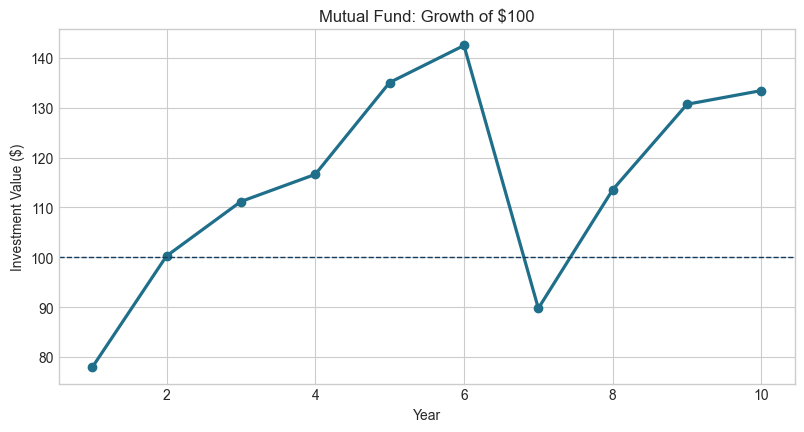

In [2]:
fund_path = Path("../../datasets/MutualFund.xlsx")
mutual_fund = pd.read_excel(fund_path, sheet_name="Data")
returns = mutual_fund["Return (%)"] / 100
arithmetic_return = returns.mean()
geometric_return = (1 + returns).prod() ** (1 / len(returns)) - 1
wealth = 100 * (1 + returns).cumprod()

print(f"Arithmetic mean return: {100 * arithmetic_return:.2f}%")
print(f"Geometric mean return: {100 * geometric_return:.2f}%")
print(f"Ending value of $100: ${wealth.iloc[-1]:.2f}")

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(mutual_fund["Year"], wealth, marker="o", color=teal, linewidth=2.3)
ax.axhline(100, color=navy, linewidth=1, linestyle="--")
ax.set_title("Mutual Fund: Growth of $100")
ax.set_xlabel("Year")
ax.set_ylabel("Investment Value ($)")
plt.show()

### Percentiles

*   The pth percentile marks a position about p percent of the way through the ordered data. For example, the 25th percentile separates roughly the lowest quarter from the remaining observations.

*   After sorting the data, calculate the percentile location as

$$
L_p=\frac{p}{100}(n+1)
$$

*   If $L_p$ is not an integer, interpolate between the observations on either side of the location.

*   A percentile is a location in an ordered distribution. It is not the percentage value of the variable.

---

### Quartiles

Quartiles are specific percentiles:

* $Q_1=P_{25}$
* $Q_2=P_{50}$, the median
* $Q_3=P_{75}$

The quartiles are calculated using the percentile location formula from the preceding slide.

---

,measure,net_sales
0,Mean,77.60
1,Median,59.71
2,Mode,31.60
3,Q1,39.60
4,Q3,101.90
5,P90,154.47


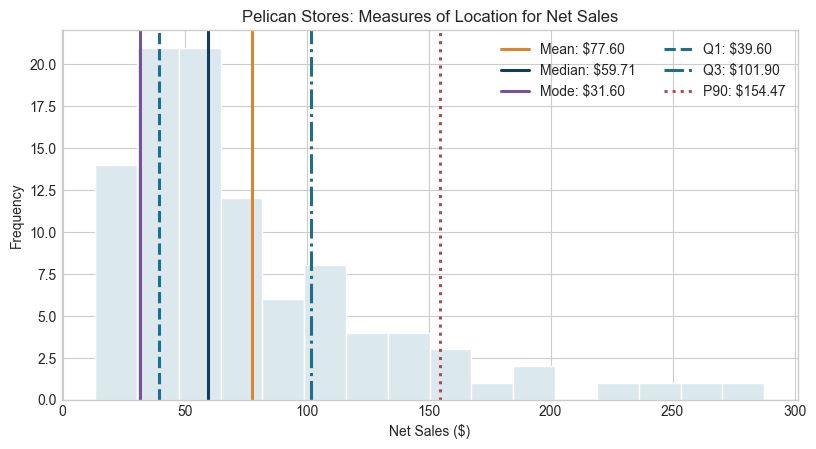

In [3]:
def interpolated_percentile(values, p):
    ordered = np.sort(np.asarray(values, dtype=float))
    location = (p / 100) * (len(ordered) + 1)
    if location <= 1:
        return ordered[0]
    if location >= len(ordered):
        return ordered[-1]
    lower_position = math.floor(location)
    fraction = location - lower_position
    lower_value = ordered[lower_position - 1]
    upper_value = ordered[lower_position]
    return lower_value + fraction * (upper_value - lower_value)

location_summary = pd.DataFrame({
    "measure": ["Mean", "Median", "Mode", "Q1", "Q3", "P90"],
    "net_sales": [
        net_sales.mean(), net_sales.median(), net_sales.mode().iloc[0],
        interpolated_percentile(net_sales, 25),
        interpolated_percentile(net_sales, 75),
        interpolated_percentile(net_sales, 90)
    ]
})
from decimal import Decimal, ROUND_HALF_UP

def display_two_decimals(value):
    return format(Decimal(f'{value:.10f}').quantize(Decimal('0.01'), rounding=ROUND_HALF_UP), '.2f')

display(location_summary.style.format({'net_sales': display_two_decimals}))

measure_styles = {
    "Mean": (orange, "-"),
    "Median": (navy, "-"),
    "Mode": ("#7a5195", "-"),
    "Q1": (teal, "--"),
    "Q3": (teal, "-."),
    "P90": ("#b04a5a", ":")
}

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(net_sales, bins=16, color="#dbe8ee", edgecolor="white")
for row in location_summary.itertuples(index=False):
    color, line_style = measure_styles[row.measure]
    ax.axvline(
        row.net_sales, color=color, linestyle=line_style, linewidth=2.2,
        label=f"{row.measure}: ${display_two_decimals(row.net_sales)}"
    )
ax.set_title("Pelican Stores: Measures of Location for Net Sales")
ax.set_xlabel("Net Sales ($)")
ax.set_ylabel("Frequency")
ax.legend(ncol=2, frameon=False)
plt.show()

### Mean, Median, Mode, and Skewness

The mean is pulled toward the longer tail. The median usually moves less because it depends on ordered position rather than the size of every observation.

| Distribution shape | Usual ordering |
|---|---|
| Negative skewness, longer left tail | Mean $<$ Median $<$ Mode |
| Symmetric and single-peaked | Mean $=$ Median $=$ Mode |
| Positive skewness, longer right tail | Mode $<$ Median $<$ Mean |

Pelican Stores net sales follow the positive-skewness pattern:

$$
\text{Mode }(\$31.60)<\text{Median }(\$59.71)<\text{Mean }(\$77.60)
$$

The ordering involving the mode is a common pattern for single-peaked distributions, not a rule for every data set.

---

### Exercise 1

A regional bank is reviewing three parts of a management report.

Customer balances

| Customer | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|
| Balance, thousand MAD | 2.0 | 2.5 | 3.0 | 3.5 | 4.0 | 80.0 |

Loan portfolio

| Loan segment | A | B | C |
|---|---:|---:|---:|
| Return, percent | 4 | 6 | 9 |
| Balance, million MAD | 60 | 30 | 10 |

Deposit growth

| Year | 1 | 2 | 3 |
|---|---:|---:|---:|
| Growth, percent | 20 | -10 | 15 |

The analyst proposes using the arithmetic mean for all three parts of the report. Which measure should be used in each case, and how should each result be interpreted?

---

### Measures of Variability

* Range
* Interquartile Range
* Variance
* Standard Deviation
* Coefficient of Variation

Measures of location do not describe how observations differ from one another. Two data sets can have the same mean and very different variability.

---

### Range and Interquartile Range

*   The range uses the two most extreme observations:

$$
\text{Range}=x_{\max}-x_{\min}
$$

*   The interquartile range covers the middle 50 percent of the ordered observations:

$$
IQR=Q_3-Q_1
$$

*   The range is highly sensitive to extreme values. 

*   The IQR is resistant but deliberately ignores variation outside the middle half.

---

### Variance

*   Variance summarizes squared deviations from the mean.

$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
\qquad
\sigma^2=\frac{\sum_{i=1}^{N}(x_i-\mu)^2}{N}
$$

*   The sample variance uses $n-1$ because it estimates population variability after the sample mean has been estimated from the same observations.

*   Squaring prevents positive and negative deviations from canceling, but it leaves variance in squared units.

---

### Standard Deviation

*   The standard deviation is the positive square root of the variance.

$$
s=\sqrt{s^2}
\qquad
\sigma=\sqrt{\sigma^2}
$$

*   Standard deviation is measured in the same units as the variable.   
    * A value of zero means that all observations are identical.

*   A standard deviation is not an average absolute distance from the mean. 
    *   Its interpretation depends on the distribution and the context.

---

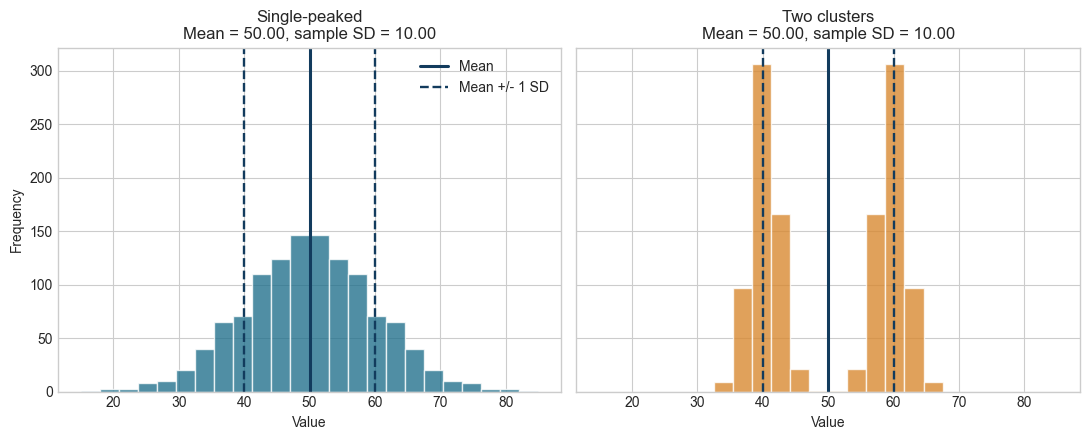

In [4]:
sd_rng = np.random.default_rng(2301)

def match_mean_and_sd(values, target_mean=50, target_sd=10):
    values = np.asarray(values, dtype=float)
    standardized = (values - values.mean()) / values.std(ddof=1)
    return target_mean + target_sd * standardized

single_side = np.abs(sd_rng.normal(size=600))
single_peaked = match_mean_and_sd(np.concatenate([-single_side, single_side]))
cluster_side = sd_rng.normal(1.3, 0.28, 600)
two_clusters = match_mean_and_sd(np.concatenate([-cluster_side, cluster_side]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
bins = np.linspace(15, 85, 25)
for ax, values, title, color in [
    (axes[0], single_peaked, "Single-peaked", teal),
    (axes[1], two_clusters, "Two clusters", orange)
]:
    mean = values.mean()
    sample_sd = values.std(ddof=1)
    ax.hist(values, bins=bins, color=color, alpha=0.78, edgecolor="white")
    ax.axvline(mean, color=navy, linewidth=2.2, label="Mean")
    ax.axvline(mean - sample_sd, color=navy, linewidth=1.7, linestyle="--", label="Mean +/- 1 SD")
    ax.axvline(mean + sample_sd, color=navy, linewidth=1.7, linestyle="--")
    ax.set_title(f"{title}\nMean = {mean:.2f}, sample SD = {sample_sd:.2f}")
    ax.set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

### Coefficient of Variation

The coefficient of variation expresses the standard deviation relative to the mean.

$$
CV=100\left(\frac{s}{\bar{x}}\right)\%
$$

It can compare relative variability when variables have different units or substantially different means.

The coefficient of variation is meaningful for ratio-scale variables with a meaningful zero and a positive mean. It becomes unstable when the mean is close to zero and is not appropriate for arbitrary interval scales.

---

In [5]:
def variability_summary(series):
    q1 = interpolated_percentile(series, 25)
    q3 = interpolated_percentile(series, 75)
    return {
        "mean": series.mean(),
        "range": series.max() - series.min(),
        "IQR": q3 - q1,
        "sample_variance": series.var(ddof=1),
        "sample_std_dev": series.std(ddof=1),
        "population_std_dev": series.std(ddof=0),
        "CV_percent": 100 * series.std(ddof=1) / series.mean()
    }

variation = pd.DataFrame({
    "Net Sales ($)": variability_summary(pelican["net_sales"]),
    "Age (years)": variability_summary(pelican["age"])
}).T
display(variation.round(2))

,mean,range,IQR,sample_variance,sample_std_dev,population_std_dev,CV_percent
Net Sales ($),77.60,274.36,62.3,3098.59,55.66,55.39,71.73
Age (years),43.08,58.00,18.0,153.49,12.39,12.33,28.76


### Exercise 2

The suppliers have the following delivery-time summaries:

| Measure | Supplier A | Supplier B |
|---|---:|---:|
| Mean | 8 days | 10 days |
| Median | 8 days | 10 days |
| Standard deviation | 2 days | 1.5 days |
| Range | 8 days | 6 days |

Management prefers Supplier A because its mean is lower. Operations prefers Supplier B because its deliveries are more consistent.

Which claim is supported by the summaries? What do the measures establish, and what additional information is needed before choosing a supplier?

---

### Skewness

*   Population moment skewness is

$$
\gamma_1=\frac{1}{N}\sum_{i=1}^{N}\left(\frac{x_i-\mu}{\sigma}\right)^3
$$

*   A common finite-sample adjustment is

$$
G_1=\frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^3
$$

*   Negative values indicate a longer left tail, values near zero indicate approximate symmetry, and positive values indicate a longer right tail. 

*    Pelican Stores net sales have adjusted sample skewness of approximately 1.71.

---

### Kurtosis

*   Pearson, or ordinary, population kurtosis is the fourth standardized central moment:

$$
\beta_2=\frac{1}{N}\sum_{i=1}^{N}\left(\frac{x_i-\mu}{\sigma}\right)^4
$$

*   Excess kurtosis subtracts the normal-distribution reference value:

$$
\gamma_2=\beta_2-3
$$

*   The adjusted sample excess kurtosis is

$$
G_2=\frac{n(n+1)}{(n-1)(n-2)(n-3)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^4-\frac{3(n-1)^2}{(n-2)(n-3)}
$$

*   A normal distribution has Pearson kurtosis 3 and excess kurtosis 0. 

*   Positive excess kurtosis indicates greater tail extremity relative to the normal distribution; negative excess kurtosis indicates less. 

*   Pelican Stores net sales have adjusted excess kurtosis of approximately 3.15 and Pearson kurtosis of approximately 6.15.

---

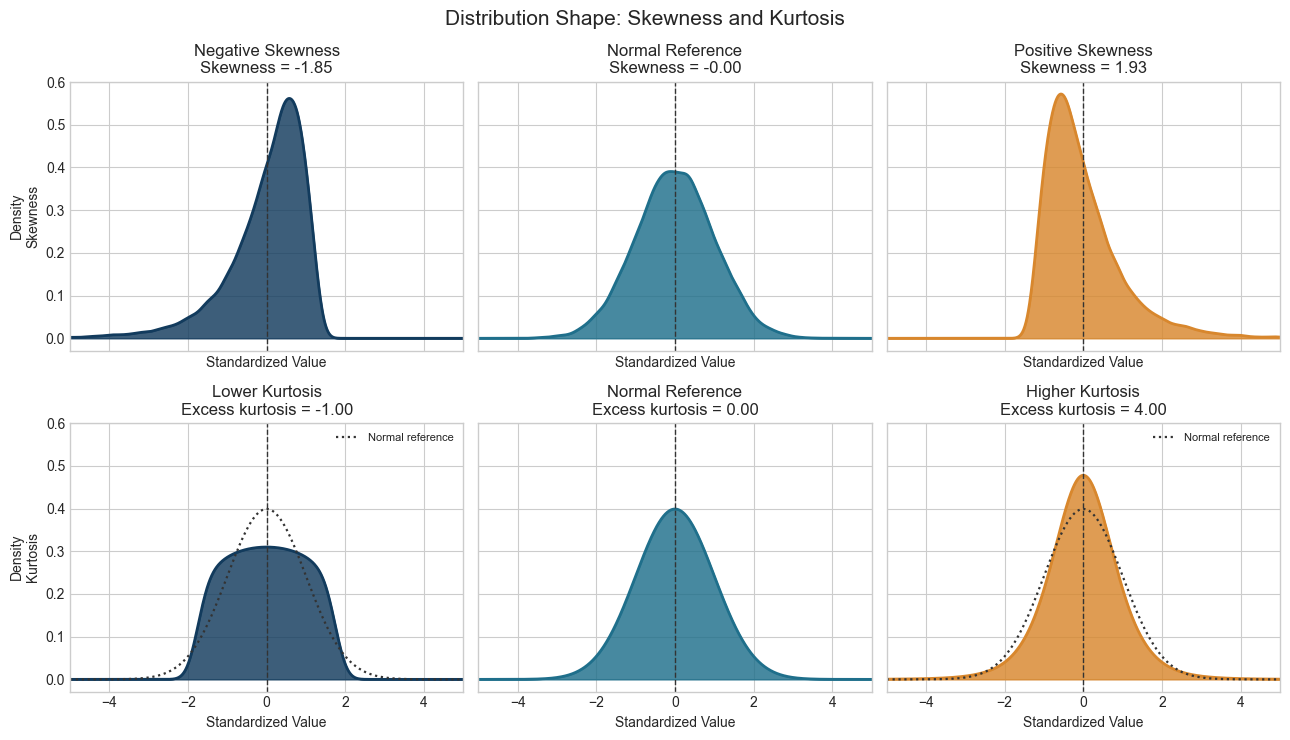

In [6]:
from scipy.integrate import trapezoid
from scipy.stats import beta, gaussian_kde, norm, t

rng = np.random.default_rng(2301)
n_shape = 20000

def standardize(values):
    values = np.asarray(values, dtype=float)
    return (values - values.mean()) / values.std(ddof=0)

skewness_examples = [
    ("Negative Skewness", standardize(-rng.lognormal(0, 0.55, n_shape)), navy),
    ("Normal Reference", standardize(rng.normal(size=n_shape)), teal),
    ("Positive Skewness", standardize(rng.lognormal(0, 0.55, n_shape)), orange)
]

x_grid = np.linspace(-5, 5, 1000)
normal_density = norm.pdf(x_grid)

lower_alpha = 1.2
lower_component_excess = -6 / (2 * lower_alpha + 3)
lower_noise_sd = np.sqrt(np.sqrt(abs(lower_component_excess)) - 1)
lower_component_sd = 1 / (2 * np.sqrt(2 * lower_alpha + 1))
lower_support = np.linspace(-np.sqrt(2 * lower_alpha + 1), np.sqrt(2 * lower_alpha + 1), 2000)
lower_component_density = (
    beta.pdf(lower_support * lower_component_sd + 0.5, lower_alpha, lower_alpha)
    * lower_component_sd
)
lower_total_sd = np.sqrt(1 + lower_noise_sd ** 2)
lower_density = lower_total_sd * trapezoid(
    lower_component_density[None, :]
    * norm.pdf(
        (lower_total_sd * x_grid[:, None] - lower_support[None, :]) / lower_noise_sd
    ) / lower_noise_sd,
    lower_support, axis=1
)

higher_df = 5.5
higher_scale = np.sqrt((higher_df - 2) / higher_df)
higher_density = t.pdf(x_grid / higher_scale, higher_df) / higher_scale

kurtosis_examples = [
    ("Lower Kurtosis", lower_density, navy, -1.00),
    ("Normal Reference", normal_density, teal, 0.00),
    ("Higher Kurtosis", higher_density, orange, 4.00)
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, (title, values, color) in zip(axes[0], skewness_examples):
    statistic = pd.Series(values).skew()
    density = gaussian_kde(values, bw_method=0.14)(x_grid)
    ax.fill_between(x_grid, density, color=color, alpha=0.82)
    ax.plot(x_grid, density, color=color, linewidth=2)
    ax.axvline(0, color="#333333", linewidth=1, linestyle="--")
    ax.set_title(f"{title}\nSkewness = {statistic:.2f}")

for ax, (title, density, color, excess) in zip(axes[1], kurtosis_examples):
    ax.fill_between(x_grid, density, color=color, alpha=0.82)
    ax.plot(x_grid, density, color=color, linewidth=2)
    if title != "Normal Reference":
        ax.plot(x_grid, normal_density, color="#333333", linewidth=1.6,
                linestyle=":", label="Normal reference")
        ax.legend(loc="upper right", frameon=False, fontsize=8)
    ax.axvline(0, color="#333333", linewidth=1, linestyle="--")
    ax.set_title(f"{title}\nExcess kurtosis = {excess:.2f}")

for ax in axes.flat:
    ax.set_xlim(-5, 5)
    ax.set_xlabel("Standardized Value")

axes[0, 0].set_ylabel("Density\nSkewness")
axes[1, 0].set_ylabel("Density\nKurtosis")
fig.suptitle("Distribution Shape: Skewness and Kurtosis", fontsize=15)
plt.tight_layout()
plt.show()

### Direct and Adjusted Calculations

For direct sample moments, let $m_r=\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^r$. Then

$$
g_1=\frac{m_3}{m_2^{3/2}},\qquad b_2=\frac{m_4}{m_2^2},\qquad g_2=b_2-3
$$

The finite-sample adjustments can be written as

$$
G_1=\frac{\sqrt{n(n-1)}}{n-2}g_1,\qquad
G_2=\frac{n-1}{(n-2)(n-3)}\left[(n+1)g_2+6\right]
$$

| Pelican Stores net sales | Direct calculation | Adjusted sample calculation | Normal reference |
|---|---:|---:|---:|
| Skewness | 1.689 | 1.715 | 0 |
| Pearson kurtosis | 5.935 | 6.150 | 3 |
| Excess kurtosis | 2.935 | 3.150 | 0 |

*   Direct and adjusted calculations lead to the same shape diagnosis, but not exactly the same numerical value. 

*   Always state whether kurtosis is Pearson or excess and whether a sample adjustment is used.

---

### z-Scores

*   A z-score measures relative location in standard-deviation units.

$$
z_i=\frac{x_i-\bar{x}}{s}
$$
* A negative z-score lies below the mean.
* A positive z-score lies above the mean.
* A z-score of zero equals the mean.

*   Standardization allows values from different scales to be compared by relative position. 
    *   It does not make differently shaped distributions equivalent.

---

### Chebyshev's Theorem and the Empirical Rule

Chebyshev's theorem applies to any distribution. For $k>1$, at least

$$
1-\frac{1}{k^2}
$$

of the observations lie within k standard deviations of the mean. The empirical rule requires an approximately bell-shaped distribution.

| Distance from mean | Chebyshev minimum | Empirical rule |
|---:|---:|---:|
| 1 standard deviation | No positive guarantee | Approximately 68 percent |
| 2 standard deviations | At least 75 percent | Approximately 95 percent |
| 3 standard deviations | At least 88.9 percent | Approximately 99.7 percent |

*   Chebyshev gives a minimum guarantee. 

*   The empirical rule gives a more precise approximation because it imposes a shape condition. 

---

### Detecting Outliers

*   Two common rules are:

* z-score rule: flag observations with $z<-3$ or $z>3$
* IQR rule: flag observations below $Q_1-1.5(IQR)$ or above $Q_3+1.5(IQR)$

*   The rules do not necessarily identify the same observations. 
    *   For Pelican Stores net sales, the IQR rule based on the quartiles above flags five observations, while the z-score rule flags three.

*   A flagged value may be a recording error, an observation from the wrong population, or a valid unusual case. 
    *   Detection requires an investigation. It does not authorize automatic deletion.

---

### Exercise 3

An analyst applies the empirical rule to Pelican Stores net sales and reports that approximately 95 percent of customers must fall within two standard deviations of the mean. 
* The analyst then removes all five observations identified by the IQR rule. 
* A colleague argues that only the three observations with z-scores above 3 should be removed. 

Audit both recommendations and state how the observations should be handled.

---

### Five-Number Summary

A five-number summary contains:

1. Smallest value
2. First quartile
3. Median
4. Third quartile
5. Largest value

Applying the percentile location formula above gives the following Pelican Stores net-sales summary:

| Minimum | Q1 | Median | Q3 | Maximum |
|---:|---:|---:|---:|---:|
| 13.23 | 39.60 | 59.71 | 101.90 | 287.59 |

---

### Box Plot

A box plot represents the quartiles, median, spread, and potential outliers.

* The box extends from $Q_1$ to $Q_3$.
* A line inside the box marks the median.
* The lower and upper fences are $Q_1-1.5(IQR)$ and $Q_3+1.5(IQR)$.
* Observations beyond the fences are plotted separately as potential outliers.

A box plot summarizes a distribution but does not show every feature that a histogram or dot plot may reveal.

---

### Comparative Box Plots

Box plots drawn on a common scale support comparisons of:

* Median location
* Middle-half variability
* Overall asymmetry
* Potential outliers

Group sizes and the percentile convention should accompany the display. A visible group difference is descriptive. It does not establish why the groups differ.

---

,N,Q1,Median,Q3,Outliers
Regular,30,39.38,51.00,74.25,2
Promotional,70,43.50,63.42,109.39,4


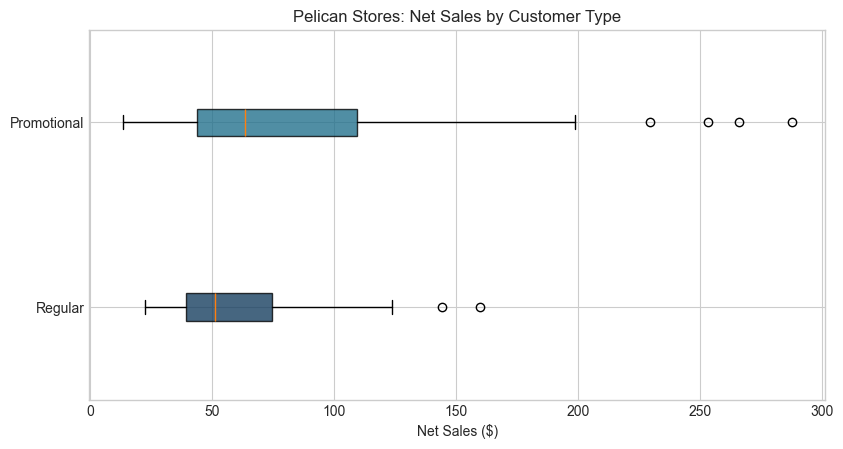

In [7]:
def build_box_stats(values, label):
    values = np.sort(np.asarray(values, dtype=float))
    q1 = interpolated_percentile(values, 25)
    median = interpolated_percentile(values, 50)
    q3 = interpolated_percentile(values, 75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    inside = values[(values >= lower_fence) & (values <= upper_fence)]
    outside = values[(values < lower_fence) | (values > upper_fence)]
    return {
        "label": label, "n": len(values), "q1": q1, "med": median, "q3": q3,
        "whislo": inside.min(), "whishi": inside.max(),
        "fliers": outside.tolist()
    }

customer_types = ["Regular", "Promotional"]
box_stats = [
    build_box_stats(pelican.loc[pelican["customer_type"] == group, "net_sales"], group)
    for group in customer_types
]

summary_by_type = pd.DataFrame({
    item["label"]: {"N": item["n"], "Q1": item["q1"], "Median": item["med"], "Q3": item["q3"], "Outliers": len(item["fliers"])}
    for item in box_stats
}).T
display(summary_by_type.style.format({
    'N': '{:.0f}', 'Q1': display_two_decimals, 'Median': display_two_decimals,
    'Q3': display_two_decimals, 'Outliers': '{:.0f}'
}))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
artists = ax.bxp(box_stats, showfliers=True, patch_artist=True, vert=False)
for box, color in zip(artists["boxes"], [navy, teal]):
    box.set_facecolor(color)
    box.set_alpha(0.78)
ax.set_title("Pelican Stores: Net Sales by Customer Type")
ax.set_xlabel("Net Sales ($)")
plt.show()

### Exercise 4

The comparative box plots show that promotional customers have a higher median net sale and a wider middle 50 percent. 
*   Both customer groups also contain observations beyond their group-specific upper IQR fences. 
*   Management concludes that promotional status increases customer spending and proposes ending efforts directed at regular customers.

Does the display support management's conclusion? 

What can be concluded from the box plots and data structure, and what further analysis is needed?

---

### Covariance

*   Covariance measures the direction of linear association between two quantitative variables.

$$
s_{xy}=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{n-1}
\qquad
\sigma_{xy}=\frac{\sum_{i=1}^{N}(x_i-\mu_x)(y_i-\mu_y)}{N}
$$

*   A positive covariance indicates that the variables tend to move in the same direction. A negative covariance indicates opposite movement.

*   Its magnitude depends on the measurement units. 

*   Rescaling either variable changes the covariance, so magnitude alone does not provide a standardized measure of strength.

---

### Correlation Coefficient

*   Correlation standardizes covariance:

$$
r_{xy}=\frac{s_{xy}}{s_xs_y}
\qquad
\rho_{xy}=\frac{\sigma_{xy}}{\sigma_x\sigma_y}
$$

*   Correlation ranges from -1 to 1 and measures the direction and strength of linear association. 

*   A correlation near zero can coexist with a strong nonlinear relationship. 
*   Correlation can also be sensitive to unusual observations. 
*   High correlation does not establish causation.

---

Sample covariance: 115.00 item-dollars
Sample correlation: 0.755


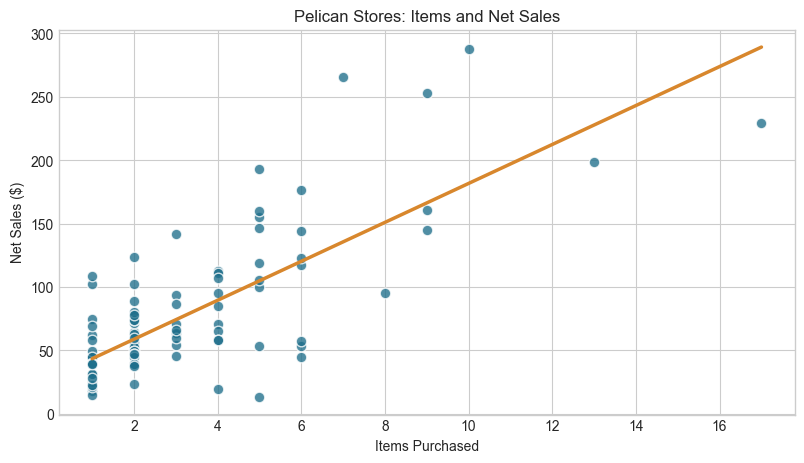

In [8]:
sample_covariance = pelican[["items", "net_sales"]].cov().loc["items", "net_sales"]
sample_correlation = pelican[["items", "net_sales"]].corr().loc["items", "net_sales"]
slope, intercept = np.polyfit(pelican["items"], pelican["net_sales"], 1)
trend_x = np.linspace(pelican["items"].min(), pelican["items"].max(), 100)

print(f"Sample covariance: {sample_covariance:.2f} item-dollars")
print(f"Sample correlation: {sample_correlation:.3f}")

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.scatter(pelican["items"], pelican["net_sales"], s=58, color=teal, alpha=0.78, edgecolor="white")
ax.plot(trend_x, intercept + slope * trend_x, color=orange, linewidth=2.5)
ax.set_title("Pelican Stores: Items and Net Sales")
ax.set_xlabel("Items Purchased")
ax.set_ylabel("Net Sales ($)")
plt.show()

### Exercise 5

Five stores report the following values for two series. Both series have meaningful zero values.

| Store | Series X | Series Y |
|---|---:|---:|
| A | 2 | 8 |
| B | 4 | 14 |
| C | 6 | 6 |
| D | 8 | 10 |
| E | 10 | 12 |

*   For each series, calculate the mean, median, sample variance, sample standard deviation, and coefficient of variation. 

*   Calculate the sample covariance and correlation between Series X and Series Y.

---

### What is next?

* Introduction to Probability I
    * Random Experiments, Counting Rules, and Assigning Probabilities
    * Events and Their Probabilities
    * Some Basic Relationships of Probability
    * Reading(s):
        * SBE: Ch. 4.1 to 4.3

---

### Exercise 6

A retailer compares two fulfillment centers:

| Measure | Center North | Center South |
|---|---:|---:|
| Orders processed | 9,200 | 2,100 |
| Median fulfillment time | 18 hours | 22 hours |
| Mean fulfillment time | 24 hours | 23 hours |
| Standard deviation | 20 hours | 6 hours |
| IQR | 11 hours | 8 hours |
| Observations above the upper IQR fence | 34 | 4 |

Management plans to move all volume to Center North because its median is lower.
   *   Does the lower median justify that decision? 
   *   Compare speed, variability, unusual observations, and sample sizes, and identify any additional evidence needed.

---

### Exercise 7

A manufacturer compares two packaging lines using 12 production days from each line.

| Measure | Line A | Line B |
|---|---:|---:|
| Mean acceptable units per day | 1,000 | 1,000 |
| Median | 1,010 | 1,080 |
| Sample standard deviation | 50 | 260 |
| First quartile | 975 | 1,010 |
| Third quartile | 1,035 | 1,130 |
| Minimum | 910 | 250 |
| Maximum | 1,080 | 1,180 |

Management prefers Line B because its median and quartiles are higher. Finance considers the lines equivalent because their means are equal. The 250-unit day for Line B coincides with a reported stoppage whose duration has not been verified.

*   Which claim is supported by the summaries? 
*   How should the 250-unit day be handled before choosing a packaging line?

---

### Exercise 8

Rif Valley Capital is deciding whether to include the mutual fund represented in MutualFund.xlsx in a retirement plan. The committee's report cites only the arithmetic mean return and the best annual return. Does the available evidence support including the fund? Which numerical measures and displays should guide the decision, and what cannot be concluded from these data?

---